In [ ]:
import os
import sys
import math
import json
import re
import csv
import random
import hashlib
import multiprocessing as mp
from dataclasses import dataclass
from datetime import datetime
from functools import partial
from itertools import accumulate
from typing import Any, Dict, Optional, Union, List
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset

from tqdm.notebook import tqdm
from tqdm.auto import tqdm as tqdm_auto

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

import xgboost as xgb

from litellm import completion



In [2]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", trust_remote_code=True)

In [4]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 94,327


In [5]:
dataset[6]


{'main_category': 'Appliances',
 'title': 'WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003',
 'average_rating': 4.6,
 'rating_number': 323,
 'features': ['【PARTS NUMBER】The WD12X10327 dishwasher top rack wheels and stud assembly Kit （4 pcs）',
  '【SCOPE OF APPLICATION】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud',
  '【REPLACES PART】1811003, AP4980629, WD12X0330, WD12X0356, WD12X0357, WD12X0383, WD12X0385, WD12X10327, WD12X330, WD12X356, WD12X357, WD12X383, WD12X385',
  '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure',
  '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask

In [6]:
max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

The most expensive item is TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it costs 21,095.62


In [ ]:

MIN_CHARS = 600
MIN_PRICE = 0.5
MAX_PRICE = 999.49
MAX_TEXT_EACH = 3000
MAX_TEXT_TOTAL = 4000

REMOVALS = [
    "Part Number",
    "Best Sellers Rank",
    "Batteries Included?",
    "Batteries Required?",
    "Item model number",
]

PARTNO_RE = re.compile(r"\b(?=[A-Z0-9]{7,}\b)(?=.*[A-Z])(?=.*\d)[A-Z0-9]+\b")
WEIGHT_RE = re.compile(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*([a-zA-Z]+)(?:\s+([a-zA-Z]+))?\s*$")


@dataclass
class Item:
    id: str
    title: str
    category: str
    price: float
    full: str
    weight: float


def get_item_id(dp: Dict[str, Any]) -> str:
   
    for k in ("parent_asin", "asin", "product_id", "item_id", "id"):
        v = dp.get(k)
        if v:
            return str(v)

    
    base = (str(dp.get("title", "")) + "||" + str(dp.get("details", ""))).encode("utf-8", "ignore")
    return hashlib.sha1(base).hexdigest()[:16]


def simplify(text: Union[str, List[str], None]) -> str:
    if not text:
        return ""
    if isinstance(text, list):
        text = " ".join(str(x) for x in text if x is not None)
    else:
        text = str(text)

    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text[:MAX_TEXT_EACH]


def scrub(title: Any, description: Any, features: Any, details: Dict[str, Any]) -> str:
    details = dict(details) if details else {}

    for remove in REMOVALS:
        details.pop(remove, None)

    result_parts = [str(title).strip() if title is not None else ""]
    if description:
        result_parts.append(simplify(description))
    if features:
        result_parts.append(simplify(features))
    if details:
        try:
            result_parts.append(json.dumps(details, ensure_ascii=False))
        except TypeError:
            result_parts.append(json.dumps({k: str(v) for k, v in details.items()}, ensure_ascii=False))

    result = "\n".join(p for p in result_parts if p).strip()
    result = PARTNO_RE.sub("", result)
    result = re.sub(r"\s+", " ", result).strip()
    return result[:MAX_TEXT_TOTAL]


def get_weight(details: Dict[str, Any]) -> float:
    if not details:
        return 0.0

    weight_str = details.get("Item Weight")
    if not weight_str:
        return 0.0

    weight_str = str(weight_str).strip().lower().replace(",", "")
    parts = weight_str.split()

    # Special case: "NN hundredths pounds"
    if len(parts) >= 3 and parts[1] == "hundredths" and parts[2] in ("pound", "pounds"):
        try:
            return float(parts[0]) / 100.0
        except (ValueError, TypeError):
            return 0.0

    m = WEIGHT_RE.match(weight_str)
    if not m:
        return 0.0

    try:
        amount = float(m.group(1))
    except (ValueError, TypeError):
        return 0.0

    unit = (m.group(2) or "").lower()
    unit3 = (m.group(3) or "").lower()

    if unit in ("lb", "lbs", "pound", "pounds"):
        return amount
    if unit in ("oz", "ounce", "ounces"):
        return amount / 16.0
    if unit in ("g", "gram", "grams"):
        return amount / 453.592
    if unit in ("mg", "milligram", "milligrams"):
        return amount / 453592.0
    if unit in ("kg", "kilogram", "kilograms"):
        return amount / 0.453592
    if unit == "hundredths" and unit3 in ("pound", "pounds"):
        return amount / 100.0

    return 0.0


def parse(datapoint: Dict[str, Any], category: str) -> Optional[Item]:
    
    try:
        price = float(datapoint.get("price"))
    except (ValueError, TypeError):
        return None

    if not (MIN_PRICE <= price <= MAX_PRICE):
        return None

    title = datapoint.get("title") or ""
    description = datapoint.get("description")
    features = datapoint.get("features")

    
    raw_details = datapoint.get("details")
    if isinstance(raw_details, dict):
        details = raw_details
    else:
        try:
            details = json.loads(raw_details) if raw_details else {}
        except (json.JSONDecodeError, TypeError):
            details = {}

    weight = get_weight(details)
    full = scrub(title, description, features, details)

    if len(full) < MIN_CHARS:
        return None

    item_id = get_item_id(datapoint)

    return Item(
        id=item_id,
        title=str(title),
        category=category,
        price=price,
        full=full,
        weight=weight,
    )

In [8]:
items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 34,559 items from 94,327 datapoints


In [9]:
items[0]

Item(id='B07W42P978', title='WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003', category='Appliances', price=8.99, full='Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces 1811003 【PARTS NUMBER】The dishwasher top rack wheels and stud assembly Kit （4 pcs） 【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud 【 PART】, , , , , , , , , , , , 【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure 【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund {"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "Whi

In [10]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces 1811003 【PARTS NUMBER】The dishwasher top rack wheels and stud assembly Kit （4 pcs） 【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud 【 PART】, , , , , , , , , , , , 【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure 【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund {"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud assembly Kit", "Styl

In [11]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

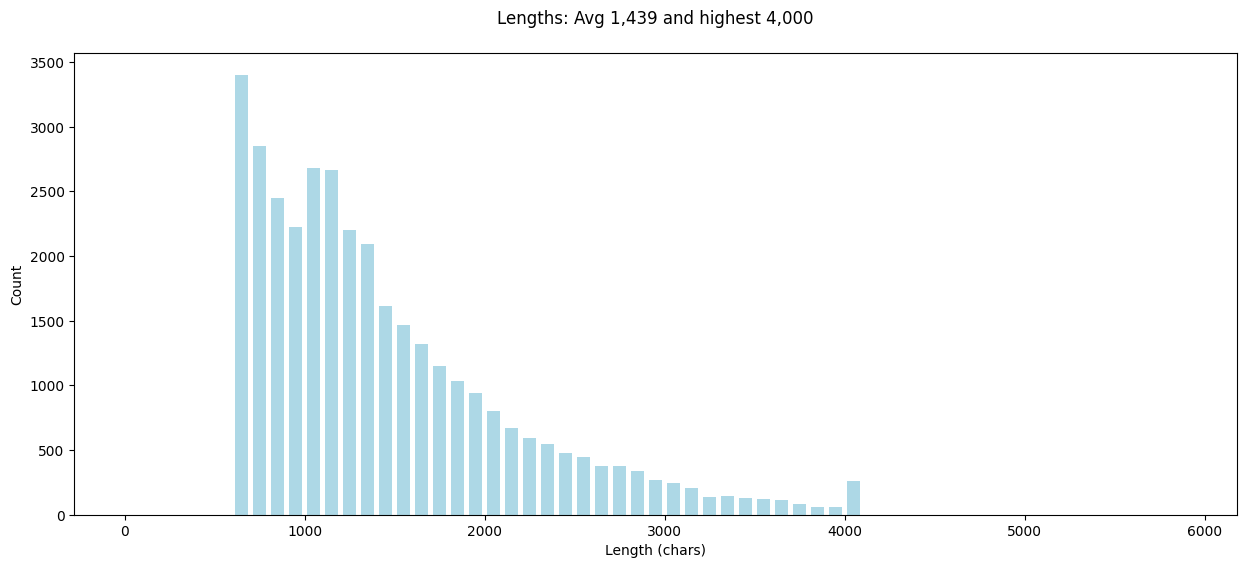

In [12]:
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [13]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12 ✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality. ✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent. ✅【WIDE 】--- These polyester filters are designed to f

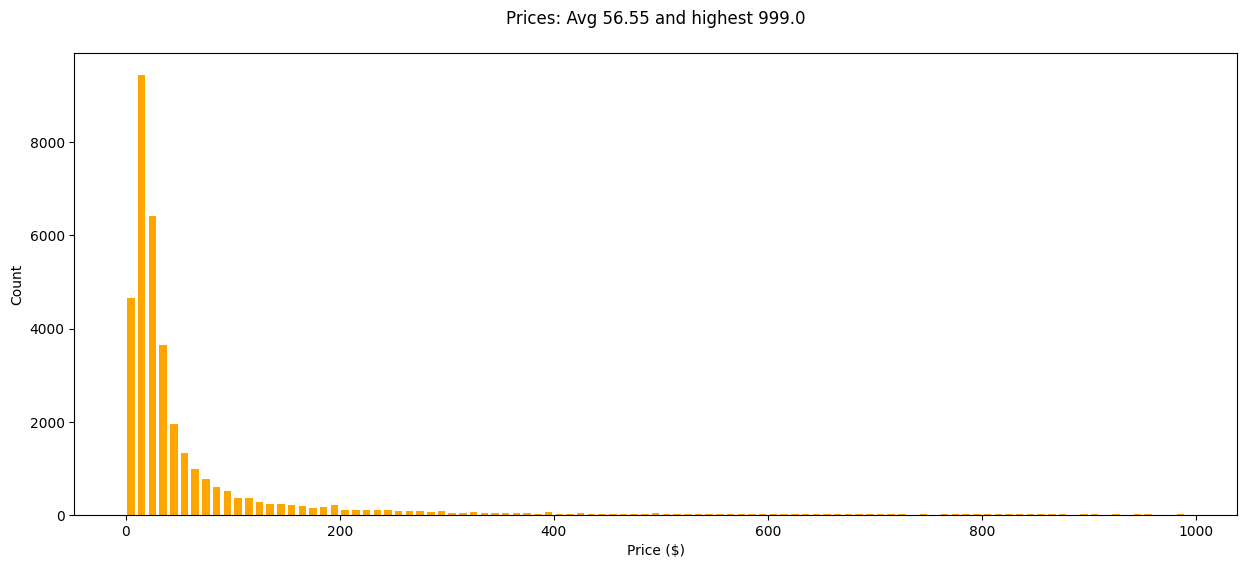

In [14]:
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [15]:
print(items[3].full)

MLGB Stainless Steel Brushed Pattern Dishwasher Magnet Cover Panel Decal Home Appliance Art, Stainless Steel Fridge Door Cover Decals Magnetic, Black, Mobile Magnetic 23" x 26" Stainless Steel Brushed Pattern Magnetic Dishwasher Panel Covers allow you to easily transform your kitchen as the seasons change. You can instantly get rid of outdated and/or mismatched appliances, will give your kitchen a refreshing look. : Vinyl + rubber magnet Occasion: Magnet Dishwasher Cover Decor dishwasher covers and any metal device surface with magnetism. 【Kitchen Dishwasher Covers SIZE】S - 23 W x 17 H inches; 58.5 W x 43 H cm;L - 23 W x 26 H inches; 58.5 W x 66 H cm; Attention: Just ensure that your dishwasher is magnetic before ordering the dishwasher cover magnet Due to the inconsistent calibration of the monitor, the colors on the computer monitor may be slightly different. Quality service: If you have any questions or questions, please feel free to contact us and we will reply within 24 hours to p

In [ ]:
CHUNK_SIZE = 1000

cpu_count = os.cpu_count() or 2
WORKERS = max(cpu_count - 1, 1)


def process_chunk(chunk, category):
    out = []
    for dp in chunk:
        item = parse(dp, category)  
        if item is not None:
            out.append(item)
    return out


class ItemLoader:
    def __init__(self, category):
        self.category = category
        self.dataset = None

    def chunk_generator(self):
        size = len(self.dataset)
        for start in range(0, size, CHUNK_SIZE):
            end = min(start + CHUNK_SIZE, size)
            
            yield [self.dataset[i] for i in range(start, end)]

    def load_in_parallel(self, workers):
        results = []
        size = len(self.dataset)
        chunk_count = math.ceil(size / CHUNK_SIZE)

        fn = partial(process_chunk, category=self.category)

        
        if sys.platform != "win32":
            ctx = mp.get_context("fork")
            with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as pool:
                for batch in tqdm(pool.map(fn, self.chunk_generator()), total=chunk_count):
                    results.extend(batch)
        else:
            
            with ProcessPoolExecutor(max_workers=workers) as pool:
                for batch in tqdm(pool.map(fn, self.chunk_generator()), total=chunk_count):
                    results.extend(batch)

        return results

    def load(self, workers=WORKERS):
        start = datetime.now()
        print(f"Loading dataset {self.category}", flush=True)

        self.dataset = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            f"raw_meta_{self.category}",
            split="full",
            trust_remote_code=True,
        )

        items = self.load_in_parallel(workers)

        finish = datetime.now()
        mins = (finish - start).total_seconds() / 60.0
        print(
            f"Completed {self.category}: {len(items):,} items from {len(self.dataset):,} datapoints in {mins:.1f} mins",
            flush=True,
        )
        return items


loader = ItemLoader("Appliances")
items = loader.load()


Loading dataset Appliances


  0%|          | 0/95 [00:00<?, ?it/s]

Completed Appliances: 34,559 items from 94,327 datapoints in 0.2 mins


In [17]:

dataset_names = [
    "Appliances",
    #"Electronics",
    "Office_Products",
    #"Tools_and_Home_Improvement",
    #"Cell_Phones_and_Accessories",
    #"Toys_and_Games",
    #"Appliances",
    "Musical_Instruments",
]

In [18]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Appliances


  0%|          | 0/95 [00:00<?, ?it/s]

Completed Appliances: 34,559 items from 94,327 datapoints in 0.2 mins
Loading dataset Office_Products


  0%|          | 0/711 [00:00<?, ?it/s]

Completed Office_Products: 247,191 items from 710,503 datapoints in 1.4 mins
Loading dataset Musical_Instruments


  0%|          | 0/214 [00:00<?, ?it/s]

Completed Musical_Instruments: 68,096 items from 213,593 datapoints in 0.6 mins


In [19]:
print(f"A grand total of {len(items):,} items")


A grand total of 349,846 items


In [20]:
items[1000]

Item(id='B09DDBQ9MJ', title='Whole Parts Washing Machine Main Center Tub Seal Assembly Part # 5303279394 - Replacement & Compatible With Some Frigidaire Washers - Non-OEM Frigidaire Appliance Parts & Accessories - 2 Yr Warranty', category='Appliances', price=34.25, full='Whole Parts Washing Machine Main Center Tub Seal Assembly Part # - Replacement & Compatible With Some Frigidaire Washers - Non-OEM Frigidaire Appliance Parts & Accessories - 2 Yr Warranty Compatible Parts Models , 461, , , , , , -100, -200, , , , , Compatible Appliance Models , , , , , , , , , , , , , , , , , , , , , , , , 417., , , , , , , , , , , , , , , 417.91702, , , , , , , , , , , , , , , , , , , , , , , 417., 417., , , , , , , , , , , , , 417.927022, , , , , , , , , , , 417.948123, 417.948623, 417., 417., , , , , , , , , , , , , , , , , , 417., 417.938122, 417.948023, , , , , , , , , , , , , , , 417., 417.938022, , , , , , , , , , , , , , , , , , , , 417.9087299 🔧 Whole Parts # Washer Tub Water Seal Kit. This Pa

In [21]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

  0%|          | 0/349846 [00:00<?, ?it/s]

  0%|          | 0/342867 [00:00<?, ?it/s]

After deduplication, we have 341,949 items


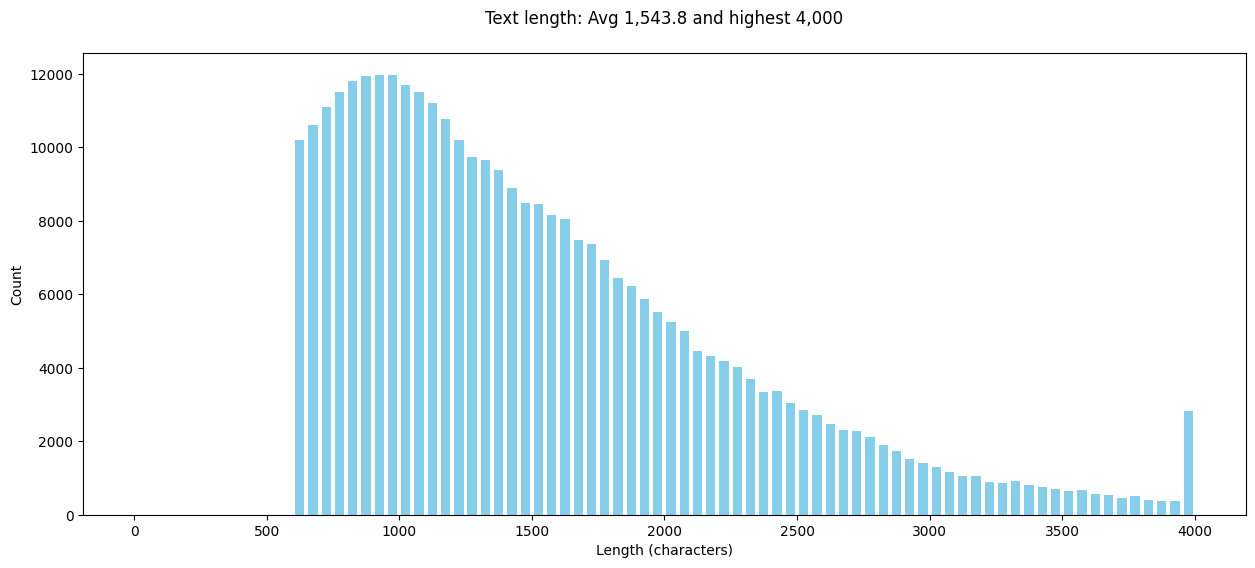

In [22]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

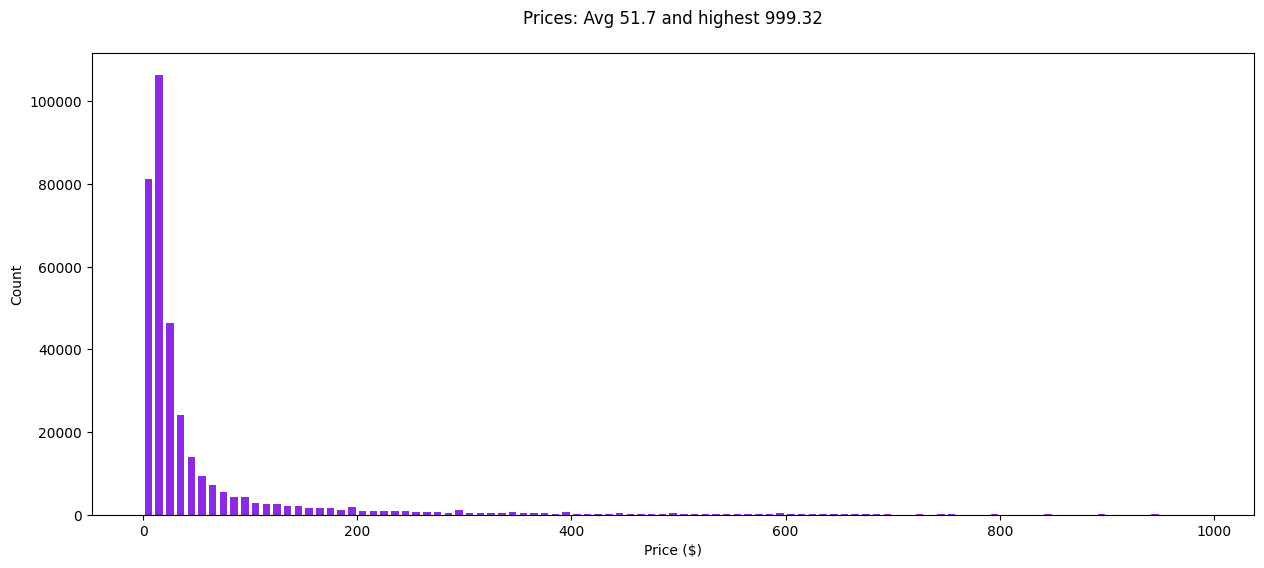

In [23]:

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

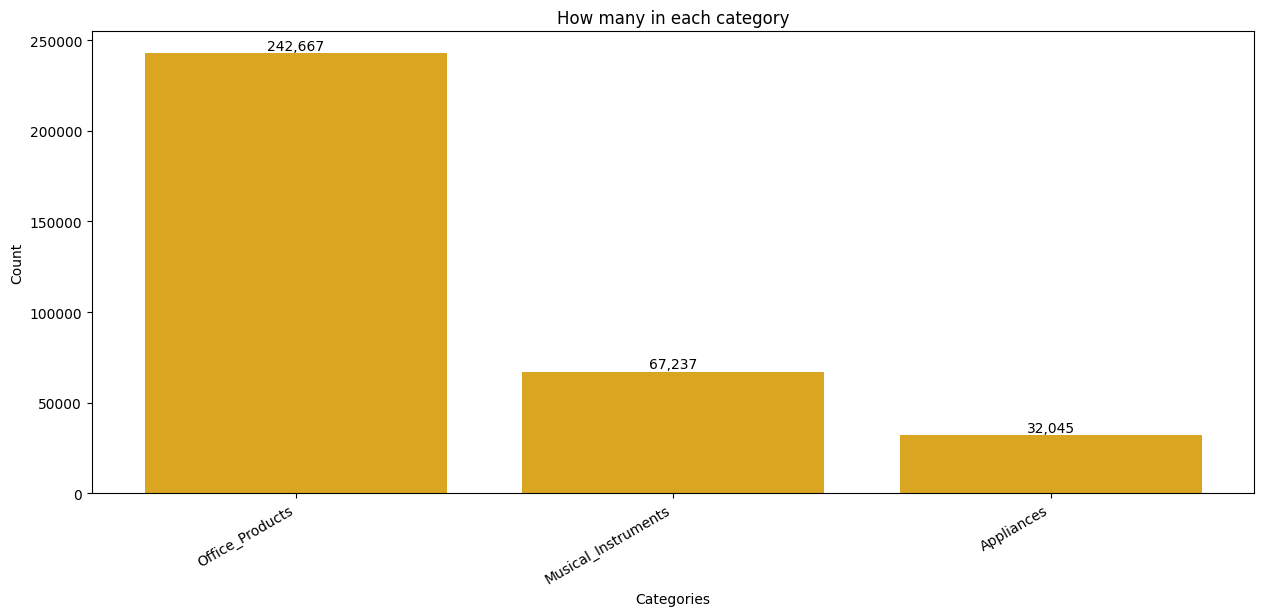

In [24]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [ ]:
np.random.seed(42)

SIZE = 820_000
SIZE = min(SIZE, len(items))

prices = np.array([it.price for it in items], dtype=float)
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w = w + 1e-12          
w = w / w.sum()

idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]

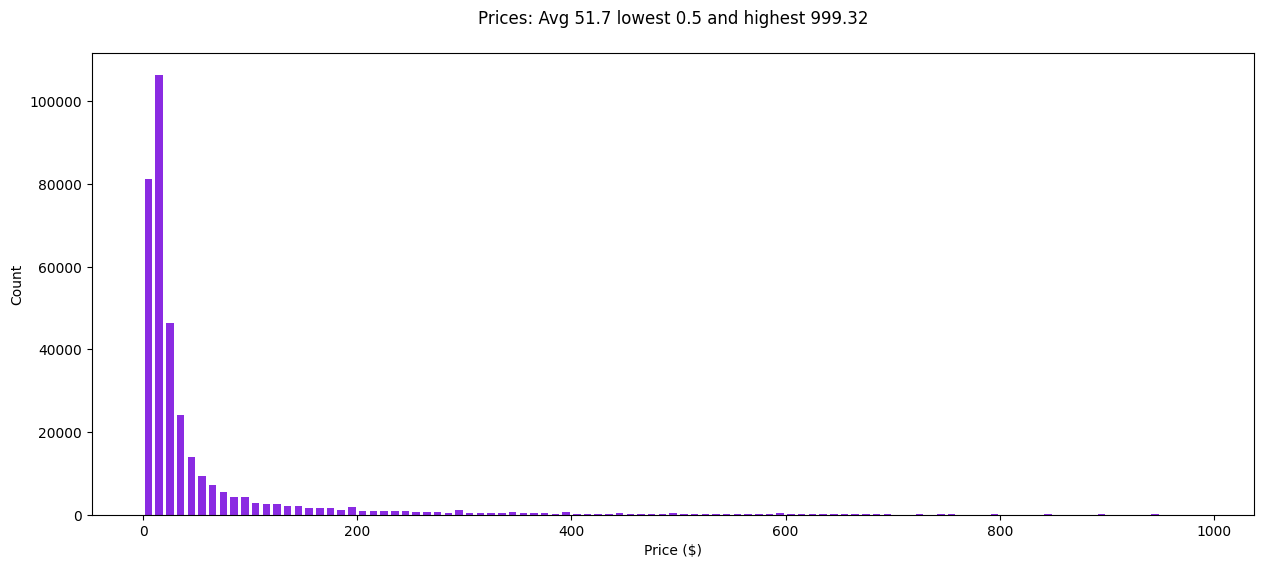

In [26]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [27]:
random.seed(42)
random.shuffle(sample)

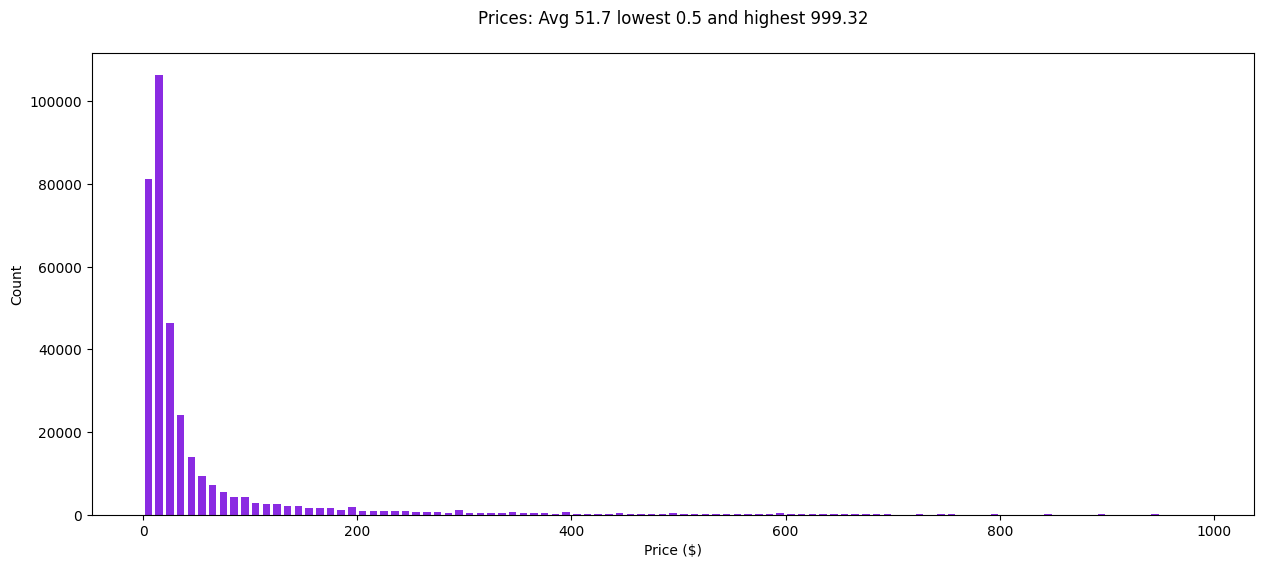

In [28]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

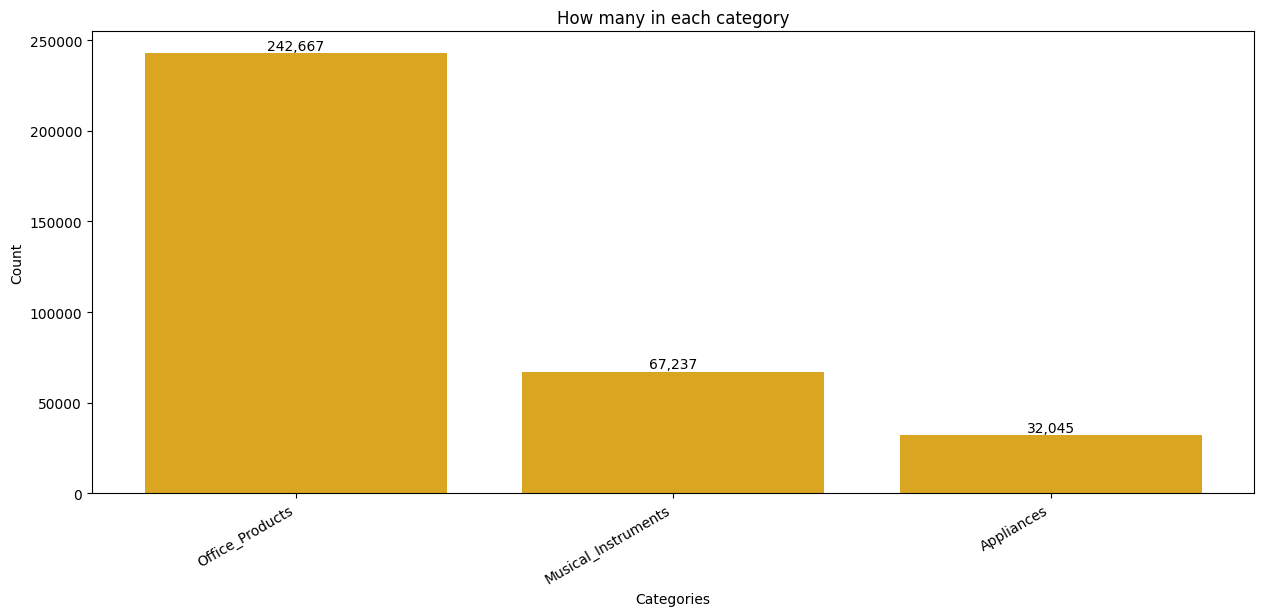

In [ ]:

category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]


plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')


for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')


plt.show()

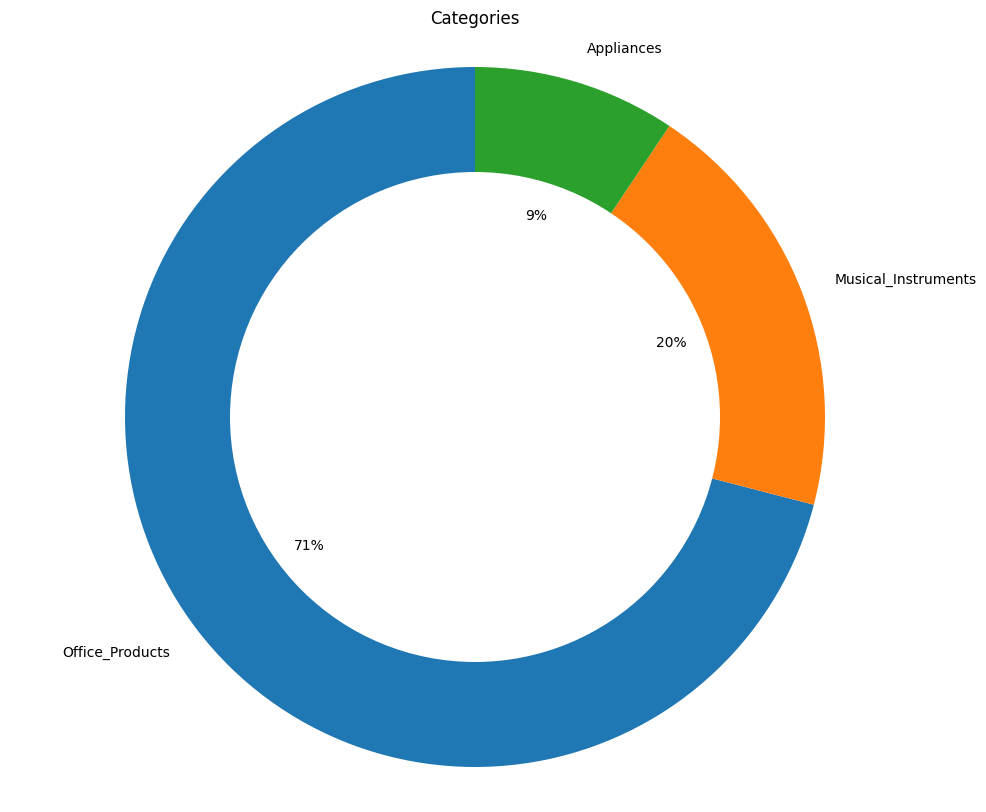

In [ ]:
plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)


centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')
plt.axis('equal')  

plt.show()

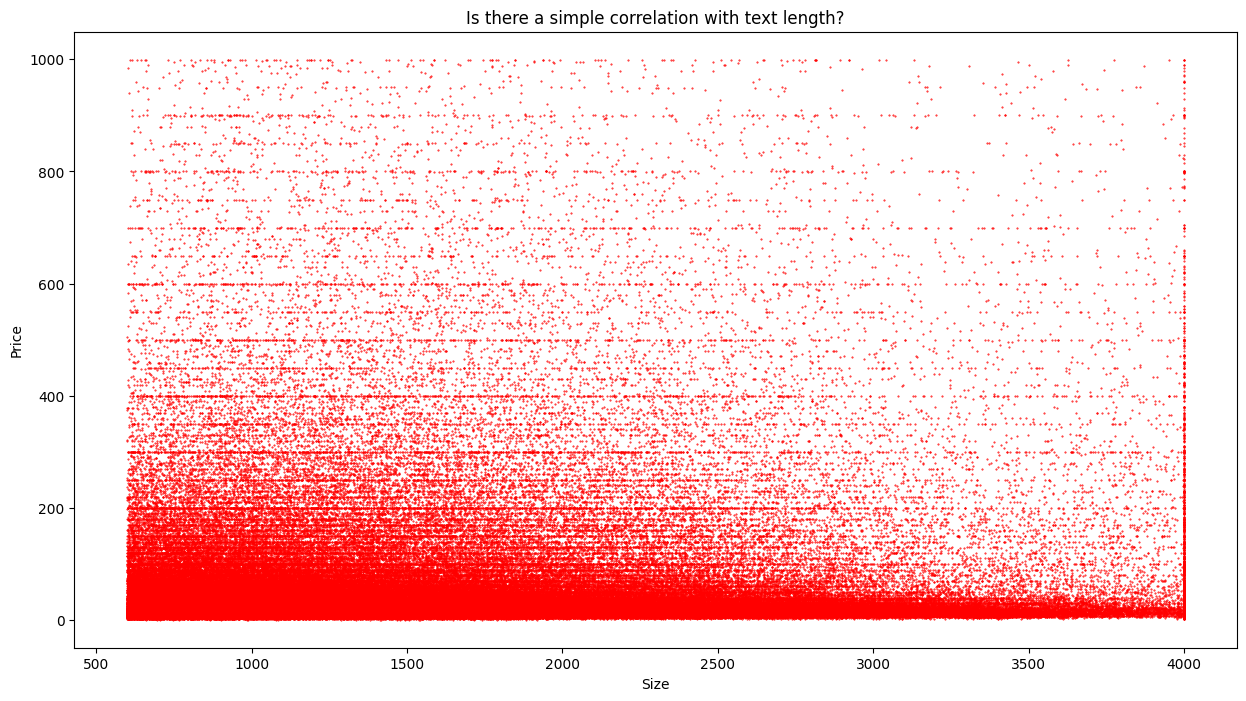

In [ ]:
sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]


plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")


plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')


plt.show()

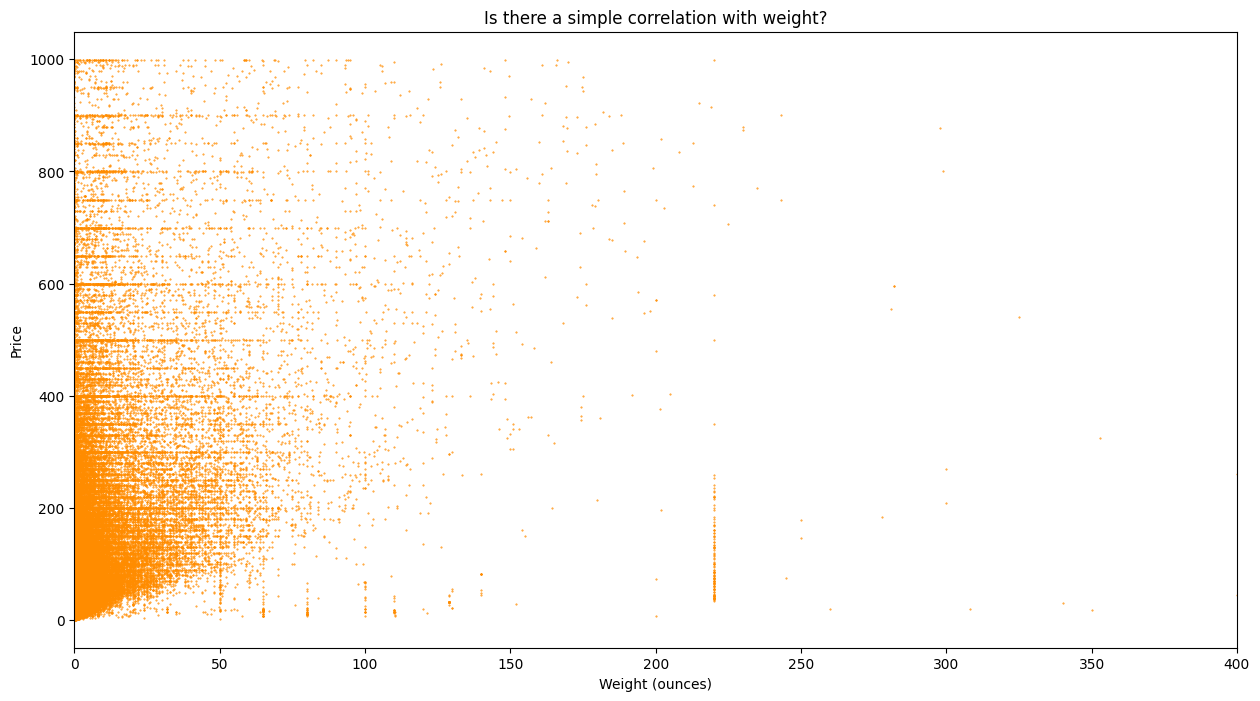

In [ ]:

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]


plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")


plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')


plt.show()

In [33]:
items=items[:25000]

In [34]:
items[2].id

'B081P3GGKN'

In [35]:
len(items)

25000

In [36]:
for index, item in enumerate(items):
    item.id = index

In [37]:
SYSTEM_PROMPT = """Create a concise description of a product. Respond only in this format. Do not include part numbers.
Title: Rewritten short precise title
Category: eg Electronics
Brand: Brand name
Description: 1 sentence description
Details: 1 sentence on features"""

In [38]:
print(items[0].full)

Juvale 30 Pack Kids All About Me Classroom Posters for Kindergarten, Elementary School Students (17 x 22 In) Motivate your students into making friends and getting to know others in their class thanks to these kids' classroom posters. This set of 30 "All About Me" student posters is great for kids to share about themselves and learn about their peers. They are excellent for star student posters. Each DIY poster includes spaces to fill in personal information such as favorite food, song, season, and more! It even has a spot for students to draw a picture of themselves. Ideal teaching supply to distribute to students in the classroom and made of offset paper. Each classroom poster measures 17 x 22 inches and can be easily hung with push pins or tape. All About Me Poster Set: Decorate your preschool, kindergarten, or 1st-grade walls with these cute DIY poster decorations that are excellent for classrooms and help encourage students to talk among each other and learn about their peers Grea

In [ ]:


messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": items[0].full}]
response = completion(messages=messages, model="ollama/llama3.2", api_base="http://localhost:11434")
print(response.choices[0].message.content)
print()
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cost: {response._hidden_params['response_cost']*100:.3f} cents")

### Classroom Decor
Category: Education Supplies
Brand: Juvale
Description: A set of 30 DIY posters that encourage kids to share about themselves and learn about their peers.
Details: Each poster features blank spaces for kids to fill in personal information and includes a spot for them to draw a picture of themselves.

Input tokens: 514
Output tokens: 65
Cost: 0.000 cents


In [40]:
len(items)

25000

In [ ]:
def chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

CHUNK_SIZE = 100 


for batch_no, batch in enumerate(chunked(items, CHUNK_SIZE), start=1):
    print(batch_no, len(batch), batch[0].id)
    


1 100 0
2 100 100
3 100 200
4 100 300
5 100 400
6 100 500
7 100 600
8 100 700
9 100 800
10 100 900
11 100 1000
12 100 1100
13 100 1200
14 100 1300
15 100 1400
16 100 1500
17 100 1600
18 100 1700
19 100 1800
20 100 1900
21 100 2000
22 100 2100
23 100 2200
24 100 2300
25 100 2400
26 100 2500
27 100 2600
28 100 2700
29 100 2800
30 100 2900
31 100 3000
32 100 3100
33 100 3200
34 100 3300
35 100 3400
36 100 3500
37 100 3600
38 100 3700
39 100 3800
40 100 3900
41 100 4000
42 100 4100
43 100 4200
44 100 4300
45 100 4400
46 100 4500
47 100 4600
48 100 4700
49 100 4800
50 100 4900
51 100 5000
52 100 5100
53 100 5200
54 100 5300
55 100 5400
56 100 5500
57 100 5600
58 100 5700
59 100 5800
60 100 5900
61 100 6000
62 100 6100
63 100 6200
64 100 6300
65 100 6400
66 100 6500
67 100 6600
68 100 6700
69 100 6800
70 100 6900
71 100 7000
72 100 7100
73 100 7200
74 100 7300
75 100 7400
76 100 7500
77 100 7600
78 100 7700
79 100 7800
80 100 7900
81 100 8000
82 100 8100
83 100 8200
84 100 8300
85 100 8400
8

In [42]:
train = items[:20_000]
val = items[20_000:21_000]
test = items[21_000:]

In [ ]:


GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red": RED, "orange": YELLOW, "green": GREEN}

WORKERS = 5
DEFAULT_SIZE = 200


class Tester:
    def __init__(self, predictor, data, title=None, size=DEFAULT_SIZE, workers=WORKERS, verbose=True):
        self.predictor = predictor
        self.data = data
        self.title = title or self.make_title(predictor)
        self.size = min(size, len(data))  
        self.titles = []
        self.guesses = []
        self.truths = []
        self.errors = []
        self.colors = []
        self.workers = workers
        self.verbose = verbose

    @staticmethod
    def make_title(predictor) -> str:
        name = getattr(predictor, "__name__", str(predictor))
        return name.replace("__", ".").replace("_", " ").title().replace("Gpt", "GPT")

    @staticmethod
    def post_process(value):
        """
        Convert predictor output to float safely.
        """
        if value is None:
            return 0.0

        
        if isinstance(value, (int, float)):
            if isinstance(value, float) and (math.isnan(value) or math.isinf(value)):
                return 0.0
            return float(value)

        
        if isinstance(value, str):
            v = value.replace("$", "").replace(",", "")
            match = re.search(r"[-+]?\d*\.\d+|\d+", v)
            return float(match.group()) if match else 0.0

        
        try:
            return float(value)
        except Exception:
            return 0.0

    def color_for(self, error, truth):
        """
        Avoid divide-by-zero when truth==0
        """
        truth = float(truth) if truth not in (None, "") else 0.0
        if truth <= 0:
            
            if error < 40:
                return "green"
            elif error < 80:
                return "orange"
            return "red"

        ratio = error / truth
        if error < 40 or ratio < 0.2:
            return "green"
        elif error < 80 or ratio < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]

        
        try:
            value = self.predictor(datapoint)
        except Exception:
            value = 0.0

        guess = self.post_process(value)

        # truth (guarded)
        truth = getattr(datapoint, "price", None)
        try:
            truth = float(truth)
        except Exception:
            truth = 0.0

        error = abs(guess - truth)
        color = self.color_for(error, truth)

        title = getattr(datapoint, "title", "")
        title = str(title)
        title = title if len(title) <= 40 else title[:40] + "..."

        return title, guess, truth, error, color

    def chart(self, title):
        if not self.truths:
            print("No results to plot.")
            return

        df = pd.DataFrame(
            {
                "truth": self.truths,
                "guess": self.guesses,
                "title": self.titles,
                "error": self.errors,
                "color": self.colors,
            }
        )

        
        df["hover"] = [
            f"{t}\nGuess=${g:,.2f} Actual=${y:,.2f}"
            for t, g, y in zip(df["title"], df["guess"], df["truth"])
        ]

        
        max_val = float(
            max(
                df["truth"].max(skipna=True),
                df["guess"].max(skipna=True),
                1.0,
            )
        )

        fig = px.scatter(
            df,
            x="truth",
            y="guess",
            color="color",
            color_discrete_map={"green": "green", "orange": "orange", "red": "red"},
            title=title,
            labels={"truth": "Actual Price", "guess": "Predicted Price"},
            width=1000,
            height=800,
        )

        
        for tr in fig.data:
            mask = df["color"] == tr.name
            tr.customdata = df.loc[mask, ["hover"]].to_numpy()
            tr.hovertemplate = "%{customdata[0]}<extra></extra>"
            tr.marker.update(size=6)

        
        fig.add_trace(
            go.Scatter(
                x=[0, max_val],
                y=[0, max_val],
                mode="lines",
                line=dict(width=2, dash="dash", color="deepskyblue"),
                name="y = x",
                hoverinfo="skip",
                showlegend=False,
            )
        )

        fig.update_xaxes(range=[0, max_val])
        fig.update_yaxes(range=[0, max_val])
        fig.update_layout(showlegend=False)
        fig.show()

    def error_trend_chart(self):
        n = len(self.errors)
        if n == 0:
            print("No errors to plot.")
            return

        running_sums = list(accumulate(self.errors))
        x = list(range(1, n + 1))
        running_means = [s / i for s, i in zip(running_sums, x)]

        running_squares = list(accumulate(e * e for e in self.errors))
        running_stds = [
            math.sqrt((sq_sum / i) - (mean**2)) if i > 1 else 0
            for i, sq_sum, mean in zip(x, running_squares, running_means)
        ]

        ci = [1.96 * (sd / math.sqrt(i)) if i > 1 else 0 for i, sd in zip(x, running_stds)]
        upper = [m + c for m, c in zip(running_means, ci)]
        lower = [m - c for m, c in zip(running_means, ci)]

        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                x=x + x[::-1],
                y=upper + lower[::-1],
                fill="toself",
                fillcolor="rgba(128,128,128,0.2)",
                line=dict(color="rgba(255,255,255,0)"),
                hoverinfo="skip",
                showlegend=False,
                name="95% CI",
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=running_means,
                mode="lines",
                line=dict(width=3, color="firebrick"),
                name="Cumulative Avg Error",
                customdata=list(zip(ci)),
                hovertemplate=(
                    "n=%{x}<br>"
                    "Avg Error=$%{y:,.2f}<br>"
                    "±95% CI=$%{customdata[0]:,.2f}<extra></extra>"
                ),
            )
        )

        final_mean = running_means[-1]
        final_ci = ci[-1]
        title = f"{self.title} Error: ${final_mean:,.2f} ± ${final_ci:,.2f}"

        fig.update_layout(
            title=title,
            xaxis_title="Number of Datapoints",
            yaxis_title="Average Absolute Error ($)",
            width=1000,
            height=360,
            template="plotly_white",
            showlegend=False,
        )

        fig.show()

    def report(self):
        n = len(self.errors)
        if n == 0:
            print("No datapoints evaluated.")
            return

        average_error = sum(self.errors) / n
        mse = mean_squared_error(self.truths, self.guesses)
        r2 = r2_score(self.truths, self.guesses) * 100

        title = (
            f"{self.title} results<br>"
            f"<b>Error:</b> ${average_error:,.2f} "
            f"<b>MSE:</b> {mse:,.0f} "
            f"<b>r²:</b> {r2:.1f}%"
        )

        self.error_trend_chart()
        self.chart(title)

    def run(self):
        with ThreadPoolExecutor(max_workers=self.workers) as ex:
            for title, guess, truth, error, color in tqdm(
                ex.map(self.run_datapoint, range(self.size)),
                total=self.size,
            ):
                self.titles.append(title)
                self.guesses.append(guess)
                self.truths.append(truth)
                self.errors.append(error)
                self.colors.append(color)

                if self.verbose:
                    print(f"{COLOR_MAP[color]}${error:.0f} {RESET}", end="")

        if self.verbose:
            print() 

        self.report()


def evaluate(function, data, size=DEFAULT_SIZE, workers=WORKERS, verbose=True):
    Tester(function, data, size=size, workers=workers, verbose=verbose).run()


In [45]:
def random_pricer(item):
    return random.randrange(1,1000)

In [46]:
random.seed(42)
evaluate(random_pricer, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$374 $303 $3 $707 $259 $152 $216 $134 $568 $96 $303 $739 $905 $479 $79 $515 $423 $17 $45 $89 $166 $227 $498 $567 $14 $538 $197 $690 $506 $702 $551 $418 $196 $440 $466 $268 $756 $752 $6 $730 $802 $155 $652 $308 $325 $262 $144 $134 $966 $249 $334 $59 $57 $120 $70 $356 $369 $230 $610 $260 $802 $37 $713 $457 $536 $118 $980 $934 $168 $69 $523 $290 $830 $637 $625 $872 $868 $364 $575 $138 $712 $67 $31 $667 $214 $786 $284 $46 $759 $200 $879 $59 $310 $267 $449 $644 $841 $365 $127 $375 $95 $204 $678 $26 $703 $935 $680 $641 $58 $610 $634 $76 $539 $721 $233 $154 $440 $360 $273 $942 $631 $652 $557 $160 $672 $329 $854 $764 $731 $37 $194 $791 $28 $814 $316 $396 $257 $58 $206 $921 $376 $572 $884 $717 $315 $163 $665 $496 $399 $873 $805 $583 $442 $134 $263 $107 $243 $753 $525 $537 $260 $720 $509 $418 $821 $582 $353 $331 $85 $18 $516 $478 $84 $729 $33 $874 $147 $149 $624 $142 $688 $606 $423 $583 $36 $347 $379 $461 $446 $478 $238 $956 $304 $845 $917 $8 $417 $726 $74 $619 


In [47]:
training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)
print(training_average)

def constant_pricer(item):
    return training_average

52.06658099999433


In [48]:
evaluate(constant_pricer, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$229 $366 $23 $1 $29 $47 $39 $43 $135 $43 $338 $32 $43 $28 $41 $38 $42 $36 $24 $45 $6 $40 $32 $2 $38 $15 $45 $8 $108 $35 $44 $40 $22 $32 $86 $35 $21 $87 $39 $4 $28 $43 $11 $73 $28 $29 $36 $35 $38 $481 $41 $6 $14 $218 $22 $40 $447 $71 $43 $41 $27 $44 $17 $38 $38 $42 $35 $41 $168 $40 $9 $41 $32 $45 $43 $17 $37 $45 $35 $7 $42 $47 $36 $41 $33 $46 $39 $17 $65 $13 $43 $7 $28 $34 $36 $45 $38 $43 $12 $47 $407 $41 $43 $196 $36 $27 $32 $29 $36 $38 $35 $47 $44 $26 $34 $38 $18 $23 $48 $46 $27 $1 $38 $13 $22 $48 $42 $29 $12 $31 $11 $1 $47 $41 $44 $37 $34 $42 $41 $37 $538 $43 $38 $33 $44 $3 $45 $36 $45 $19 $80 $24 $24 $39 $43 $16 $42 $42 $2 $37 $42 $7 $38 $31 $47 $36 $4 $12 $88 $108 $46 $24 $42 $7 $36 $44 $208 $44 $33 $30 $72 $39 $42 $24 $22 $4 $40 $98 $18 $12 $32 $13 $211 $15 $3 $32 $228 $39 $8 $28 


In [49]:
def get_features(item):
    w = getattr(item, "weight", 0) or 0
    text = getattr(item, "summary", None) or getattr(item, "full", None) or getattr(item, "title", "")
    
    return {
        "weight": float(w),
        "weight_unknown": 1 if float(w) == 0.0 else 0,
        "text_length": len(text),
    }


In [ ]:


def list_to_dataframe(items):
    rows = []
    prices = []

    for item in items:
        feat = get_features(item) or {}
        rows.append(feat)

        
        try:
            prices.append(float(getattr(item, "price", 0.0)))
        except (TypeError, ValueError):
            prices.append(0.0)

    df = pd.DataFrame(rows)

    
    for col in ["weight", "weight_unknown", "text_length"]:
        if col not in df.columns:
            df[col] = 0

    df["price"] = prices
    return df


train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test)


In [ ]:
np.random.seed(42)


feature_columns = ['weight', 'weight_unknown', 'text_length']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']


model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 4.99570254476524
weight_unknown: 7.837378967947619
text_length: 0.004757889895026342
Intercept: 31.025943213107766
Mean Squared Error: 6134.049727397578
R-squared Score: 0.28754669984688386


In [52]:
def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

In [53]:
evaluate(linear_regression_pricer, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$49 $341 $10 $17 $18 $35 $24 $30 $150 $32 $295 $27 $28 $44 $25 $37 $35 $24 $39 $29 $19 $33 $21 $5 $24 $2 $35 $15 $116 $419 $32 $24 $13 $20 $37 $31 $1 $94 $23 $6 $16 $32 $7 $78 $41 $21 $28 $13 $29 $263 $25 $1 $1 $233 $10 $35 $429 $76 $32 $36 $18 $31 $10 $27 $26 $31 $20 $38 $424 $26 $3 $27 $14 $30 $31 $7 $24 $39 $31 $21 $35 $29 $24 $40 $24 $34 $22 $4 $26 $36 $28 $7 $30 $25 $24 $29 $22 $32 $4 $40 $421 $28 $34 $209 $35 $24 $18 $21 $21 $25 $22 $47 $32 $19 $31 $28 $3 $20 $32 $36 $19 $11 $23 $30 $11 $32 $31 $39 $19 $21 $10 $8 $31 $29 $32 $26 $35 $33 $32 $27 $556 $29 $22 $16 $30 $5 $33 $29 $30 $3 $96 $1 $9 $30 $45 $9 $32 $28 $8 $30 $31 $6 $50 $18 $53 $19 $4 $18 $51 $89 $43 $15 $25 $18 $44 $27 $34 $28 $27 $25 $87 $6 $30 $15 $23 $9 $28 $94 $1 $21 $25 $6 $154 $9 $11 $28 $31 $27 $3 $47 


In [ ]:

def item_text(item) -> str:
    
    return (
        getattr(item, "summary", None)
        or getattr(item, "full", None)
        or getattr(item, "title", "")
        or ""
    )

def safe_price(item) -> float:
    try:
        return float(getattr(item, "price", 0.0))
    except (TypeError, ValueError):
        return 0.0



prices = np.array([safe_price(item) for item in train], dtype=float)
documents = [item_text(item) for item in train]


y = np.log1p(prices)


vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)
X = vectorizer.fit_transform(documents)


regressor = Ridge(alpha=2.0, random_state=42)
regressor.fit(X, y)



def natural_language_ridge_pricer(item):
    x = vectorizer.transform([item_text(item)])
    pred_log = regressor.predict(x)[0]
    pred = float(np.expm1(pred_log))          
    return max(pred, 0.0)                     



evaluate(natural_language_ridge_pricer, test, size=200, workers=1, verbose=False)


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:


subset = min(15_000, X.shape[0])


y = np.log1p(prices)


svd = TruncatedSVD(n_components=300, random_state=42)
X_small = svd.fit_transform(X[:subset])   

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_small, y[:subset])


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
def rf_text_pricer(item):
    x = vectorizer.transform([item_text(item)]) 
    x_small = svd.transform(x)                   
    pred_log = rf_model.predict(x_small)[0]
    pred = float(np.expm1(pred_log))
    return max(pred, 0.0)


In [57]:
evaluate(rf_text_pricer, test, size=200, workers=5, verbose=False)


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:

def item_text(item) -> str:
    return (
        getattr(item, "summary", None)
        or getattr(item, "full", None)
        or getattr(item, "title", "")
        or ""
    )


prices = np.array([float(it.price) for it in train], dtype=float)
documents = [item_text(it) for it in train]


X = vectorizer.fit_transform(documents)

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
xgb_model.fit(X, prices)


def xg_boost_pricer(item):
    x = vectorizer.transform([item_text(item)])
    pred = float(xgb_model.predict(x)[0])
    return max(pred, 0.0)

evaluate(xg_boost_pricer, test, size=200, workers=5, verbose=False)


  0%|          | 0/200 [00:00<?, ?it/s]

In [60]:
def messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.full}"
    return [{"role": "user", "content": message}]

In [61]:
print(test[0].full)

Drop In Ice Chest 21.2L x 16.8W x 17.6H Inch with Cover Stainless Steel Ice Cooler Included Drain-pipe and Drain Plug Drop In Ice Bin Outdoor Kitchen for Cold Wine Beverage Sturdy Structure: This drop-in ice bin is brushed 304 stainless steel material for long-lasting durability. And it is a double-walled design for better insulation work. The inside utilizes high-density insulation of foamed rubber, maintaining an interior temperature from 23℉ to 194℉, ensuring your ice stays cool for extended periods. Drop-in Design: Specification: Product Dimension: 21.2 x 16.8 x 17.6 inch; Cutout Dimension: 19.8 x 15.4 x 17.2 inch; Inner Dimension: 18.1 x 13.6 x 16.6 inch. Adopting a drop-in design won't take up much space. Meanwhile, this ice chest can accommodate drink-serving operations of nearly any size and hold up to 69.7Qt/ 66L of ice, beverages, or chilled foods. Ice Guarding Lid: The stainless steel cover can keep the cold air stay inside the ice chest and ensure the ice away from other fo

In [62]:
messages_for(test[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nDrop In Ice Chest 21.2L x 16.8W x 17.6H Inch with Cover Stainless Steel Ice Cooler Included Drain-pipe and Drain Plug Drop In Ice Bin Outdoor Kitchen for Cold Wine Beverage Sturdy Structure: This drop-in ice bin is brushed 304 stainless steel material for long-lasting durability. And it is a double-walled design for better insulation work. The inside utilizes high-density insulation of foamed rubber, maintaining an interior temperature from 23℉ to 194℉, ensuring your ice stays cool for extended periods. Drop-in Design: Specification: Product Dimension: 21.2 x 16.8 x 17.6 inch; Cutout Dimension: 19.8 x 15.4 x 17.2 inch; Inner Dimension: 18.1 x 13.6 x 16.6 inch. Adopting a drop-in design won\'t take up much space. Meanwhile, this ice chest can accommodate drink-serving operations of nearly any size and hold up to 69.7Qt/ 66L of ice, beverages, or chilled foods. Ice Guarding Lid: 

In [63]:
def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    return response.choices[0].message.content

In [64]:
gpt_4__1_nano(test[0])

'$250'

In [65]:
test[0].price

280.99

In [66]:
evaluate(gpt_4__1_nano, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$31 $32 $1 $13 $2 $51 $0 $0 $38 $1 $310 $5 $6 $20 $5 $10 $0 $5 $74 $2 $12 $3 $4 $20 $3 $7 $3 $34 $60 $28 $17 $6 $5 $4 $12 $1 $77 $11 $3 $32 $1 $4 $23 $25 $9 $3 $4 $42 $30 $33 $4 $24 $13 $120 $5 $3 $200 $73 $0 $4 $10 $8 $0 $2 $6 $3 $1 $14 $30 $8 $7 $5 $10 $3 $4 $15 $0 $9 $9 $44 $5 $2 $10 $5 $5 $2 $2 $10 $33 $9 $2 $5 $70 $7 $4 $0 $1 $3 $20 $5 $109 $2 $2 $52 $5 $0 $10 $10 $4 $1 $4 $20 $1 $0 $7 $11 $19 $3 $5 $14 $0 $97 $1 $85 $10 $9 $5 $7 $19 $4 $21 $35 $5 $8 $3 $7 $2 $1 $5 $5 $440 $4 $1 $9 $8 $125 $8 $0 $8 $25 $57 $4 $12 $2 $11 $4 $1 $5 $150 $1 $3 $0 $51 $4 $19 $6 $94 $10 $90 $339 $4 $3 $4 $105 $3 $12 $10 $0 $1 $7 $64 $59 $1 $8 $5 $28 $2 $0 $28 $44 $7 $9 $113 $21 $39 $5 $120 $2 $1 $20 


In [67]:

def gpt_5__1(item):
    response = completion(model="gpt-5.1", messages=messages_for(item), reasoning_effort='high', seed=42)
    return response.choices[0].message.content

In [68]:
evaluate(gpt_5__1, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$121 $38 $5 $2 $3 $19 $1 $2 $2 $2 $111 $10 $7 $10 $2 $50 $1 $7 $30 $1 $32 $2 $6 $0 $2 $15 $2 $24 $60 $7 $2 $7 $5 $0 $38 $3 $8 $49 $3 $28 $6 $1 $23 $6 $7 $3 $4 $21 $3 $17 $4 $24 $3 $9 $5 $3 $0 $47 $2 $2 $12 $2 $5 $2 $4 $1 $7 $4 $30 $2 $16 $3 $14 $6 $3 $15 $4 $9 $1 $24 $2 $4 $4 $1 $10 $1 $3 $11 $3 $1 $0 $15 $40 $7 $4 $2 $6 $0 $5 $0 $59 $1 $2 $118 $6 $0 $10 $9 $2 $3 $4 $20 $2 $7 $8 $1 $22 $10 $1 $9 $5 $2 $2 $15 $10 $5 $2 $6 $29 $7 $13 $34 $3 $6 $2 $9 $6 $1 $1 $5 $141 $0 $4 $9 $0 $10 $3 $4 $2 $14 $8 $36 $17 $3 $11 $6 $2 $2 $70 $3 $0 $10 $0 $4 $19 $3 $4 $0 $10 $40 $7 $1 $1 $15 $3 $12 $50 $0 $0 $4 $39 $11 $0 $18 $5 $28 $5 $20 $29 $4 $4 $4 $113 $15 $19 $6 $0 $4 $1 $20 
